In [1]:
# Installation des librairies requises pour l'inférence Stable Diffusion
!pip install -q diffusers transformers accelerate torch

In [2]:
import torch
from diffusers import StableDiffusionPipeline
import os

# Configuration de l'environnement d'exécution
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "runwayml/stable-diffusion-v1-5"
OUTPUT_DIR = "baseline_results"

# Création du répertoire de sortie
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Chargement du pipeline Stable Diffusion
# Utilisation de float16 pour optimiser l'utilisation de la VRAM du GPU
print(f"Chargement du modèle {MODEL_ID} sur {DEVICE}...")
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
)
pipe = pipe.to(DEVICE)

# Désactivation du safety checker pour éviter les faux positifs sur des objets inanimés
pipe.safety_checker = None
print("Pipeline initialisé avec succès.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Chargement du modèle runwayml/stable-diffusion-v1-5 sur cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline initialisé avec succès.


Début de la génération d'images...
[1/3] Inférence pour : 'A highly detailed photo of a toy car'


  0%|          | 0/30 [00:00<?, ?it/s]

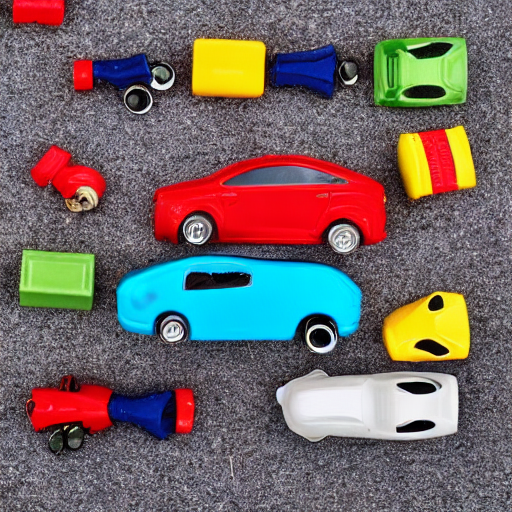

[2/3] Inférence pour : 'A photo of a plastic toy car with text written on it, studio lighting'


  0%|          | 0/30 [00:00<?, ?it/s]

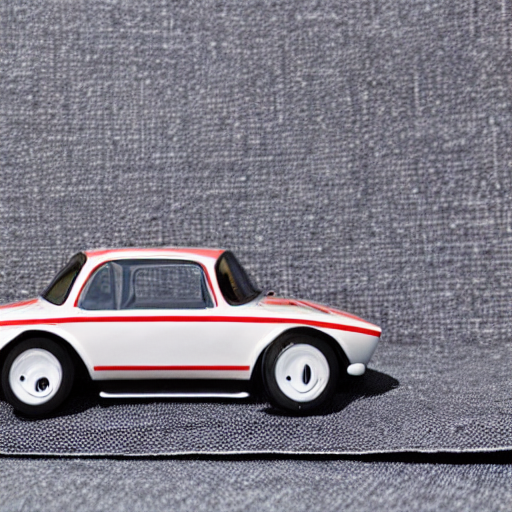

[3/3] Inférence pour : 'A toy car resting on a wooden table, 4k resolution'


  0%|          | 0/30 [00:00<?, ?it/s]

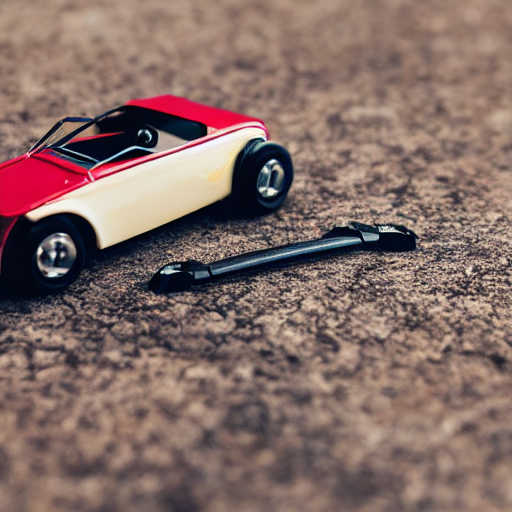

Génération terminée. Fichiers sauvegardés dans ./baseline_results/


In [3]:
# Définition des prompts de test (sans le concept cible)
# Ces prompts visent à démontrer les connaissances par défaut du modèle
prompts_baseline = [
    "A highly detailed photo of a toy car",
    "A photo of a plastic toy car with text written on it, studio lighting",
    "A toy car resting on a wooden table, 4k resolution"
]

# Paramètres d'inférence
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5

print("Début de la génération d'images...")

for idx, prompt in enumerate(prompts_baseline):
    print(f"[{idx+1}/{len(prompts_baseline)}] Inférence pour : '{prompt}'")

    # Génération
    image = pipe(
        prompt,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE
    ).images[0]

    # Affichage inline dans le notebook
    display(image)

    # Sauvegarde locale sur l'instance Colab
    file_path = os.path.join(OUTPUT_DIR, f"baseline_img_{idx+1}.png")
    image.save(file_path)

print(f"Génération terminée. Fichiers sauvegardés dans ./{OUTPUT_DIR}/")

In [4]:
# Archivage des résultats pour faciliter l'export vers l'environnement local
import shutil

ARCHIVE_NAME = "baseline_results_archive"
shutil.make_archive(ARCHIVE_NAME, 'zip', OUTPUT_DIR)

print(f"Archive créée : {ARCHIVE_NAME}.zip. Prêt pour le téléchargement.")

Archive créée : baseline_results_archive.zip. Prêt pour le téléchargement.
